# Time-Headway Distribution Fitting — by Following-Vehicle Class (PR / BTW) and by Headway Regime

This notebook extends the earlier per-`Pair` fitting exercise. Here the question is asked at a
coarser, more theoretically meaningful level: **does the time-headway distribution differ between
the two target (following) vehicle classes, `PR` and `BTW`, and does the best-fitting family change
across the range of headway values (short / medium / long headways)?**

> **Assumption flagged:** the request mentioned fitting for *"TR and BTW"*. `data3.xlsx` has no `TR`
> category — the `V_Target` column contains exactly two classes, **`BTW`** and **`PR`**. I have
> assumed `TR` was meant to be `PR`. Tell me if that's wrong and I'll redo it.

**Procedure**

1. Fit **9 candidate distributions** — `gengamma`, `weibull_min`, `gamma`, `fisk`, `lognorm`,
   `invgauss`, `rayleigh`, `expon`, `pearson3` — to `Time_Headway` separately for `PR` and `BTW`
   (pooled across all `Pair` sub-types), by maximum likelihood.
2. Score every fit with **AIC, ΔAIC, Akaike weight, BIC, KS D, KS p, Anderson–Darling A², AD p**.
3. Report the single **best** distribution by AIC per group, but also flag any distribution(s)
   within ΔAIC ≤ 2 of the best as **statistically indistinguishable ("competing")** — the brief
   asked not to force a single winner when several fits are essentially tied.
4. Split the observed `Time_Headway` range into **3 equal-width regimes** (Short / Medium / Long)
   and repeat steps 1–3 within each `V_Target × Regime` cell, to see whether the accepted family
   shifts across the headway range.

**A statistical note on the p-values.** Because the distribution parameters are estimated from the
*same* sample that the goodness-of-fit test is run on, the textbook asymptotic p-values from
`scipy.stats.kstest` (and any closed-form Anderson–Darling table) are **not valid** — they assume
the null distribution's parameters are known in advance, not fitted (the classic Lilliefors problem).
Instead, both `p (KS)` and `p (AD)` below are computed by **parametric bootstrap**: simulate many
samples from the *fitted* distribution, refit the same family to each simulated sample, and see
where the observed statistic falls in that simulated null distribution. This is slower but is the
statistically defensible way to get these p-values, and is worth keeping in the manuscript's
methods section as it will pre-empt a reviewer comment.

**A note on degenerate fits.** Three-parameter location-shifted families (`gamma`, `weibull_min`,
`fisk`, `pearson3`, ...) have a density that blows up to infinity as headway → loc⁺ whenever the
fitted shape parameter is below 1. Unconstrained MLE can then "cheat" by pinning `loc` exactly at
the sample minimum, producing an artificially huge log-likelihood and a suspiciously tiny AIC that
does not reflect a genuine fit (I hit this in testing: an unguarded `gamma` fit on one of the
regimes below returned an AIC an order of magnitude lower than every other candidate, purely from
this artifact). The code detects this numerically and refits with `loc` bounded a small margin
below the sample minimum when it happens; affected rows are flagged `Boundary_Repaired` /
`Degenerate_Fit` in the output tables rather than silently reported as the best fit.

**Where things get saved**
- Tables (Excel): `D:\Headway\Tables\headway_distribution_fits_PR_BTW.xlsx`
- Graphics (PNG): `D:\Headway\Graphics\`


In [1]:
# --- Cell 1: Imports, paths, global configuration ---
import os, time, warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ---- folders ----
BASE      = r"D:\Headway"
DATA_PATH = os.path.join(BASE, "data3.xlsx")
GRAPHICS  = os.path.join(BASE, "Graphics")
TABLES    = os.path.join(BASE, "Tables")
os.makedirs(GRAPHICS, exist_ok=True)
os.makedirs(TABLES, exist_ok=True)

# ---- variables ----
OUTCOME  = "Time_Headway"
GROUPCOL = "V_Target"          # the two classes of interest: 'PR' and 'BTW'
GROUP_ORDER = ["BTW", "PR"]

# ---- candidate distributions (exactly the 9 requested) ----
CANDIDATES = ["gengamma", "weibull_min", "gamma", "fisk", "lognorm",
              "invgauss", "rayleigh", "expon", "pearson3"]

# ---- goodness-of-fit / model-selection settings ----
ALPHA               = 0.05   # significance level for KS / AD acceptance
AIC_COMPETE_THRESH  = 2.0    # Burnham & Anderson rule of thumb: Delta_AIC <= 2 => "competing" model
MIN_N_FIT           = 15     # segments smaller than this are skipped (too few obs to fit reliably)
N_REGIMES           = 3
REGIME_LABELS       = ["Short", "Medium", "Long"]

# ---- bootstrap settings (drives the p-values; see markdown note above) ----
QUICK_MODE = True            # <-- set to False for the final, publication-quality run
N_BOOT     = 60 if QUICK_MODE else 300
RNG        = np.random.default_rng(12345)

print(f"QUICK_MODE={QUICK_MODE}  ->  N_BOOT={N_BOOT} bootstrap replicates per distribution fit")
print("Candidates:", CANDIDATES)
print("Data file :", DATA_PATH)
print("Tables -> :", TABLES)
print("Graphics->:", GRAPHICS)

QUICK_MODE=True  ->  N_BOOT=60 bootstrap replicates per distribution fit
Candidates: ['gengamma', 'weibull_min', 'gamma', 'fisk', 'lognorm', 'invgauss', 'rayleigh', 'expon', 'pearson3']
Data file : D:\Headway\data3.xlsx
Tables -> : D:\Headway\Tables
Graphics->: D:\Headway\Graphics


'V_Target' categories found in data: ['BTW', 'PR']

Time_Headway summary by V_Target:
            N   Mean     SD    Min  Median    Max
V_Target                                         
BTW       669  2.009  0.881  0.533     1.9  4.967
PR        229  2.866  1.009  0.533     3.0  4.967


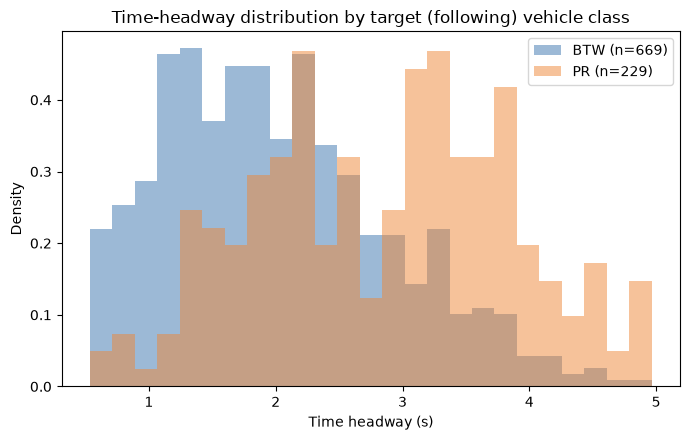

Saved: 01_headway_hist_by_target.png


In [2]:
# --- Cell 2: Load data and inspect PR / BTW headway samples ---
df = pd.read_excel(DATA_PATH)
assert OUTCOME in df.columns, f"'{OUTCOME}' column not found in {DATA_PATH}"
assert GROUPCOL in df.columns, f"'{GROUPCOL}' column not found in {DATA_PATH}"

df = df.dropna(subset=[OUTCOME, GROUPCOL]).copy()

found_groups = sorted(df[GROUPCOL].unique().tolist())
print(f"'{GROUPCOL}' categories found in data:", found_groups)
missing = [g for g in GROUP_ORDER if g not in found_groups]
if missing:
    print(f"WARNING: expected groups {GROUP_ORDER} but missing {missing}. "
          f"Using whatever is found: {found_groups}")
    GROUP_ORDER = found_groups

summary = (df.groupby(GROUPCOL)[OUTCOME]
             .agg(N="count", Mean="mean", SD="std", Min="min",
                  Median="median", Max="max")
             .loc[GROUP_ORDER]
             .round(3))
print("\nTime_Headway summary by V_Target:")
print(summary.to_string())

# quick overlaid histogram, PR vs BTW
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"BTW": "#3B75AF", "PR": "#EF8636"}
for g in GROUP_ORDER:
    data = df.loc[df[GROUPCOL] == g, OUTCOME].values
    ax.hist(data, bins=25, density=True, alpha=0.5, label=f"{g} (n={len(data)})",
            color=colors.get(g))
ax.set_xlabel("Time headway (s)")
ax.set_ylabel("Density")
ax.set_title("Time-headway distribution by target (following) vehicle class")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(GRAPHICS, "01_headway_hist_by_target.png"), dpi=300)
plt.show()
print("Saved: 01_headway_hist_by_target.png")

In [3]:
# --- Cell 3: Goodness-of-fit machinery -----------------------------------
# 3a. Anderson-Darling A^2 statistic for an arbitrary fitted continuous distribution
def ad_statistic(sorted_data, dist, params):
    '''Anderson-Darling A^2 for data already sorted ascending, given a fitted scipy dist.'''
    n = len(sorted_data)
    F = dist.cdf(sorted_data, *params)
    F = np.clip(F, 1e-12, 1 - 1e-12)
    i = np.arange(1, n + 1)
    S = np.sum((2 * i - 1) * (np.log(F) + np.log(1.0 - F[::-1])))
    return -n - S / n


# 3b. Guard against degenerate (boundary-pinned) MLE fits.
# Some 3-parameter location-shifted families (gamma, weibull_min, fisk, pearson3, ...) have a
# density that -> infinity as x -> loc+ whenever the fitted shape parameter is < 1. Unconstrained
# MLE can then pin loc exactly at min(data), producing an unbounded/artificially huge
# log-likelihood (and a suspiciously tiny AIC) that does not reflect a genuinely good fit. This is
# detected numerically (density right at the edge vs. density at the sample median); if it fires,
# we refit with loc bounded a small margin below min(data) to force a proper interior optimum.
SPIKE_RATIO_LIMIT = 1000.0

def _edge_spike_ratio(dist, params, data):
    '''Ratio of the largest density evaluated AT an observed data point to the density at the
    sample median. A boundary-pinned MLE places loc within floating-point epsilon of the nearest
    observation, so the singularity shows up exactly at that data point -- not at some arbitrary
    offset from loc -- which is why we evaluate pdf(data) directly rather than pdf(loc + eps).'''
    try:
        pdf_vals = dist.pdf(data, *params)
        pdf_max = np.nanmax(pdf_vals)
        pdf_mid = dist.pdf(np.median(data), *params)
        if not np.isfinite(pdf_max) or pdf_mid <= 0:
            return np.inf
        return pdf_max / pdf_mid
    except Exception:
        return np.inf

def safe_mle_fit(name, data):
    '''MLE-fit `name` to `data`, repairing boundary-pinned/degenerate fits where possible.
    Returns (params, boundary_repaired, degenerate).'''
    dist = getattr(stats, name)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        params = dist.fit(data)
    boundary_repaired = False
    degenerate = False
    if _edge_spike_ratio(dist, params, data) > SPIKE_RATIO_LIMIT:
        data_min, data_max = data.min(), data.max()
        margin = max(1e-6, 0.01 * max(data_max - data_min, 1e-6))
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                repaired = dist.fit(data, floc=data_min - margin)
            if _edge_spike_ratio(dist, repaired, data) < _edge_spike_ratio(dist, params, data):
                params = repaired
                boundary_repaired = True
        except Exception:
            pass
        if _edge_spike_ratio(dist, params, data) > SPIKE_RATIO_LIMIT:
            degenerate = True
    return params, boundary_repaired, degenerate


# 3c. MLE fit + AIC/BIC + KS D + AD A^2, with parametric-bootstrap p-values for KS and AD
def fit_one(name, data, n_boot, rng):
    '''Fit one scipy.stats distribution to `data` by MLE; return a metrics dict or None.'''
    dist = getattr(stats, name)
    data = np.asarray(data, dtype=float)
    n = len(data)
    try:
        params, boundary_repaired, degenerate = safe_mle_fit(name, data)
        ll = np.sum(dist.logpdf(data, *params))
        if not np.isfinite(ll):
            return None
        k = len(params)
        aic = 2 * k - 2 * ll
        bic = k * np.log(n) - 2 * ll

        ks_stat, _ = stats.kstest(data, name, args=params)          # D statistic only (naive p ignored)
        ad_stat = ad_statistic(np.sort(data), dist, params)

        # ---- parametric bootstrap null distribution for KS D and AD A^2 ----
        boot_ks = np.full(n_boot, np.nan)
        boot_ad = np.full(n_boot, np.nan)
        for b in range(n_boot):
            try:
                sim = dist.rvs(*params, size=n, random_state=rng)
                bparams, _, _ = safe_mle_fit(name, sim)
                bks, _ = stats.kstest(sim, name, args=bparams)
                bad = ad_statistic(np.sort(sim), dist, bparams)
                boot_ks[b] = bks
                boot_ad[b] = bad
            except Exception:
                continue

        valid_ks = boot_ks[~np.isnan(boot_ks)]
        valid_ad = boot_ad[~np.isnan(boot_ad)]
        ks_p = ((np.sum(valid_ks >= ks_stat) + 1) / (len(valid_ks) + 1)
                if len(valid_ks) >= 10 else np.nan)
        ad_p = ((np.sum(valid_ad >= ad_stat) + 1) / (len(valid_ad) + 1)
                if len(valid_ad) >= 10 else np.nan)

        shapes = dist.shapes
        labels = ([s.strip() for s in shapes.split(",")] if shapes else []) + ["loc", "scale"]
        param_str = ", ".join(f"{lab}={val:.4f}" for lab, val in zip(labels, params))

        return dict(Distribution=name, n_params=k, LogLik=ll, AIC=aic, BIC=bic,
                    KS_D=ks_stat, KS_p=ks_p, AD_A2=ad_stat, AD_p=ad_p,
                    Boundary_Repaired=boundary_repaired, Degenerate_Fit=degenerate,
                    Boot_valid=len(valid_ks), Params=param_str, _raw=params)
    except Exception:
        return None


# 3d. Run all 9 candidates on one data vector and assemble a ranked table.
# Degenerate (boundary-pinned) fits are still shown for transparency but are excluded from the
# AIC ranking / Delta_AIC / AIC weight / acceptance flags, and pushed to the bottom of the table.
def fit_all(data, n_boot, rng, segment_label=""):
    rows = []
    t0 = time.time()
    for name in CANDIDATES:
        r = fit_one(name, data, n_boot, rng)
        if r is None:
            print(f"    [{segment_label}] {name:<12s} FAILED to fit")
            continue
        rows.append(r)
        flag = (" [BOUNDARY-REPAIRED]" if r["Boundary_Repaired"]
                else (" [DEGENERATE]" if r["Degenerate_Fit"] else ""))
        print(f"    [{segment_label}] {name:<12s} AIC={r['AIC']:8.2f}  "
              f"KS_p={r['KS_p']:.3f}  AD_p={r['AD_p']:.3f}{flag}  "
              f"({time.time()-t0:5.1f}s elapsed)")
    out = pd.DataFrame(rows)
    if out.empty:
        return out

    ok = ~out["Degenerate_Fit"]
    out["Delta_AIC"] = np.nan
    out["AIC_weight"] = np.nan
    if ok.sum() > 0:
        base = out.loc[ok, "AIC"].min()
        out.loc[ok, "Delta_AIC"] = out.loc[ok, "AIC"] - base
        w = np.exp(-0.5 * out.loc[ok, "Delta_AIC"])
        out.loc[ok, "AIC_weight"] = w / w.sum()

    out["Accepted_KS"] = (out["KS_p"] > ALPHA) & ok
    out["Accepted_AD"] = (out["AD_p"] > ALPHA) & ok
    out["Accepted_Both"] = out["Accepted_KS"] & out["Accepted_AD"]
    out["Competing_AIC"] = (out["Delta_AIC"] <= AIC_COMPETE_THRESH) & ok

    out["_rank_key"] = np.where(ok, out["AIC"], np.inf)
    out = out.sort_values("_rank_key").reset_index(drop=True).drop(columns="_rank_key")
    out.insert(0, "AIC_Rank", np.arange(1, len(out) + 1))
    out.insert(0, "Segment", segment_label)
    out["N"] = len(data)
    return out


def run_batch(segments, scope, n_boot, rng):
    '''segments: dict{label -> 1D array of headways}. Returns concatenated results table.'''
    parts = []
    for label, data in segments.items():
        if len(data) < MIN_N_FIT:
            print(f"  SKIPPED {label}: n={len(data)} < MIN_N_FIT={MIN_N_FIT}")
            continue
        print(f"\n--- {scope}: {label}  (n={len(data)}) ---")
        res = fit_all(data, n_boot, rng, segment_label=label)
        if res.empty:
            print(f"  no successful fits for {label}")
            continue
        res.insert(0, "Scope", scope)
        parts.append(res)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

## 1. Overall fit — `PR` vs `BTW` (whole headway range)

In [4]:
# --- Cell 4: Run the 9-distribution fit for PR and BTW, whole range ---
overall_segments = {g: df.loc[df[GROUPCOL] == g, OUTCOME].values for g in GROUP_ORDER}
t_start = time.time()
overall_fits = run_batch(overall_segments, scope="Overall", n_boot=N_BOOT, rng=RNG)
print(f"\nOverall stage done in {time.time()-t_start:.1f}s")

display_cols = ["Scope", "Segment", "N", "AIC_Rank", "Distribution", "n_params", "AIC",
                 "Delta_AIC", "AIC_weight", "BIC", "KS_D", "KS_p", "AD_A2", "AD_p",
                 "Accepted_KS", "Accepted_AD", "Accepted_Both", "Competing_AIC",
                 "Boundary_Repaired", "Degenerate_Fit", "Params"]
overall_fits = overall_fits[display_cols]
overall_fits


--- Overall: BTW  (n=669) ---
    [BTW] gengamma     AIC= 1641.10  KS_p=0.262  AD_p=0.164  (  2.7s elapsed)
    [BTW] weibull_min  AIC= 1647.20  KS_p=0.738  AD_p=0.410  (  3.0s elapsed)
    [BTW] gamma        AIC= 1664.06  KS_p=0.082  AD_p=0.016  (  3.3s elapsed)
    [BTW] fisk         AIC= 1707.50  KS_p=0.016  AD_p=0.016  (  4.6s elapsed)
    [BTW] lognorm      AIC= 1673.85  KS_p=0.066  AD_p=0.033  (  4.7s elapsed)
    [BTW] invgauss     AIC= 1670.81  KS_p=0.049  AD_p=0.016  (  5.5s elapsed)
    [BTW] rayleigh     AIC= 1649.37  KS_p=0.082  AD_p=0.148  (  5.5s elapsed)
    [BTW] expon        AIC= 1862.60  KS_p=0.016  AD_p=0.016  (  5.6s elapsed)
    [BTW] pearson3     AIC= 1664.06  KS_p=0.098  AD_p=0.016  (  6.1s elapsed)

--- Overall: PR  (n=229) ---
    [PR] gengamma     AIC=  650.17  KS_p=0.131  AD_p=0.082  (  1.8s elapsed)
    [PR] weibull_min  AIC=  653.90  KS_p=0.033  AD_p=0.016  (  2.1s elapsed)
    [PR] gamma        AIC=  659.09  KS_p=0.016  AD_p=0.016  (  3.0s elapsed)
    [P

,Scope,Segment,N,AIC_Rank,Distribution,n_params,AIC,Delta_AIC,AIC_weight,BIC,...,KS_p,AD_A2,AD_p,Accepted_KS,Accepted_AD,Accepted_Both,Competing_AIC,Boundary_Repaired,Degenerate_Fit,Params
0,Overall,BTW,669,1,gengamma,4,1641.102415,0.000000,9.403668e-01,1659.125551,...,0.262295,0.430264,0.163934,True,True,True,True,False,False,"a=0.4981, c=2.6648, loc=0.5219, scale=2.4209"
1,Overall,BTW,669,2,weibull_min,3,1647.202001,6.099586,4.454397e-02,1660.719353,...,0.737705,0.411369,0.409836,True,True,True,False,False,False,"c=1.8079, loc=0.4582, scale=1.7422"
2,Overall,BTW,669,3,rayleigh,2,1649.369632,8.267217,1.506933e-02,1658.381200,...,0.081967,0.880332,0.147541,True,True,True,False,False,False,"loc=0.3812, scale=1.3087"
3,Overall,BTW,669,4,gamma,3,1664.058220,22.955805,9.738849e-06,1677.575572,...,0.081967,0.892749,0.016393,True,False,False,False,False,False,"a=3.9886, loc=0.1852, scale=0.4573"
4,Overall,BTW,669,5,pearson3,3,1664.058220,22.955805,9.738847e-06,1677.575572,...,0.098361,0.892741,0.016393,True,False,False,False,False,False,"skew=1.0015, loc=2.0090, scale=0.9132"
5,Overall,BTW,669,6,invgauss,3,1670.809180,29.706765,3.330851e-07,1684.326532,...,0.049180,0.999552,0.016393,False,False,False,False,False,False,"mu=0.1085, loc=-0.7438, scale=25.3815"
6,Overall,BTW,669,7,lognorm,3,1673.845653,32.743238,7.297825e-08,1687.363005,...,0.065574,1.069407,0.032787,True,False,False,False,False,False,"s=0.3178, loc=-0.7745, scale=2.6481"
7,Overall,BTW,669,8,fisk,3,1707.495541,66.393126,3.599259e-15,1721.012893,...,0.016393,2.076006,0.016393,False,False,False,False,False,False,"c=4.7480, loc=-0.4851, scale=2.3579"
8,Overall,BTW,669,9,expon,2,1862.600537,221.498123,7.509156e-49,1871.612106,...,0.016393,40.602137,0.016393,False,False,False,False,False,False,"loc=0.5333, scale=1.4756"
9,Overall,PR,229,1,gengamma,4,650.166336,0.000000,8.386074e-01,663.901224,...,0.131148,0.463478,0.081967,True,True,True,True,False,False,"a=0.3242, c=5.7278, loc=0.4447, scale=3.7661"


In [5]:
# --- Cell 5: Best distribution + "competing set" per group (overall) ---
def summarize_best(fits_df):
    rows = []
    for seg, sub in fits_df.groupby("Segment", sort=False):
        best = sub.loc[sub["AIC_Rank"] == 1].iloc[0]
        competing = sub.loc[(sub["Competing_AIC"]) & (sub["AIC_Rank"] != 1), "Distribution"].tolist()
        rows.append(dict(
            Scope=best["Scope"], Segment=seg, N=best["N"],
            Best_Distribution=best["Distribution"], AIC=best["AIC"],
            KS_p=best["KS_p"], AD_p=best["AD_p"], Accepted_Both=best["Accepted_Both"],
            Best_Boundary_Repaired=best["Boundary_Repaired"],
            N_Competing=len(competing),
            Competing_Distributions=", ".join(competing) if competing else "(none within \u0394AIC\u22642)"
        ))
    return pd.DataFrame(rows)

overall_best = summarize_best(overall_fits)
overall_best

,Scope,Segment,N,Best_Distribution,AIC,KS_p,AD_p,Accepted_Both,Best_Boundary_Repaired,N_Competing,Competing_Distributions
0,Overall,BTW,669,gengamma,1641.102415,0.262295,0.163934,True,False,0,(none within ΔAIC≤2)
1,Overall,PR,229,gengamma,650.166336,0.131148,0.081967,True,False,0,(none within ΔAIC≤2)


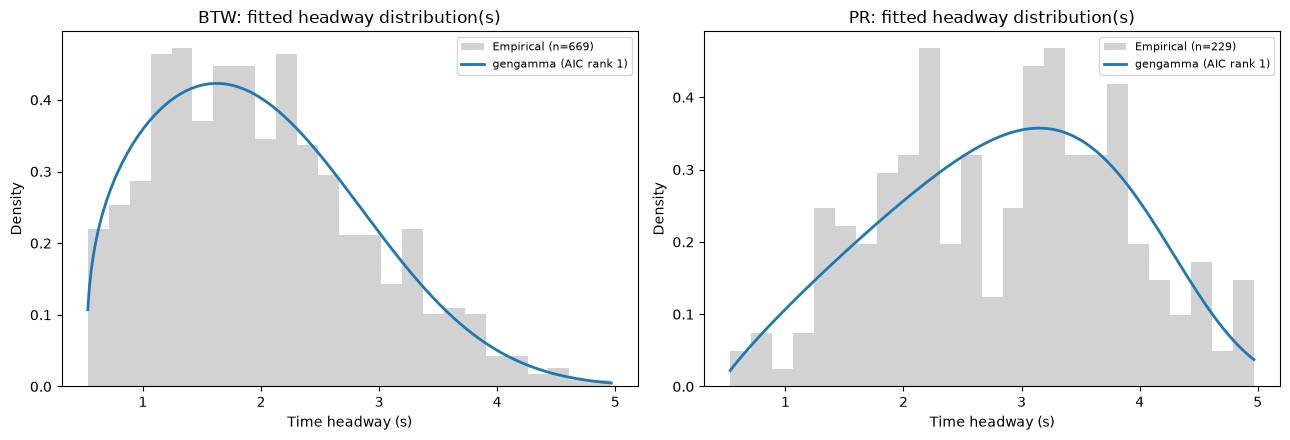

Saved: 02_overall_fit_PR_BTW.png


In [6]:
# --- Cell 6: Overlay best-fit PDF(s) on histograms, PR and BTW (overall) ---
fig, axes = plt.subplots(1, len(GROUP_ORDER), figsize=(6.5 * len(GROUP_ORDER), 4.5), squeeze=False)
axes = axes[0]

for ax, g in zip(axes, GROUP_ORDER):
    data = overall_segments[g]
    sub = overall_fits[overall_fits["Segment"] == g].sort_values("AIC_Rank")
    ax.hist(data, bins=25, density=True, alpha=0.35, color="gray", label=f"Empirical (n={len(data)})")
    xg = np.linspace(data.min(), data.max(), 300)
    top = sub[sub["Competing_AIC"]] if sub["Competing_AIC"].sum() > 1 else sub.head(1)
    for _, row in top.iterrows():
        dist = getattr(stats, row["Distribution"])
        raw_params = [float(v.split("=")[1]) for v in row["Params"].split(", ")]
        yg = dist.pdf(xg, *raw_params)
        ax.plot(xg, yg, lw=2, label=f"{row['Distribution']} (AIC rank {row['AIC_Rank']})")
    ax.set_title(f"{g}: fitted headway distribution(s)")
    ax.set_xlabel("Time headway (s)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(GRAPHICS, "02_overall_fit_PR_BTW.png"), dpi=300)
plt.show()
print("Saved: 02_overall_fit_PR_BTW.png")

## 2. Splitting the headway range into 3 regimes

The observed `Time_Headway` range is split into **3 equal-width bins** ("Short", "Medium", "Long")
using the pooled min/max across both classes (both classes share essentially the same observed
range, so a single set of cut points is valid for a like-for-like comparison across `V_Target`).
The 9-distribution fit is then repeated **within each `V_Target × Regime` cell**.

Regime cut points (s):
Regime  Lower_s  Upper_s
 Short    0.533    2.011
Medium    2.011    3.489
  Long    3.489    4.967

Sample sizes by V_Target x Regime:
                      N   Mean    Min    Max
V_Target TH_Regime                          
BTW      Short      367  1.358  0.533  2.000
         Medium     256  2.600  2.033  3.467
         Long        46  3.915  3.500  4.967
PR       Short       52  1.513  0.533  2.000
         Medium     109  2.777  2.033  3.467
         Long        68  4.041  3.500  4.967


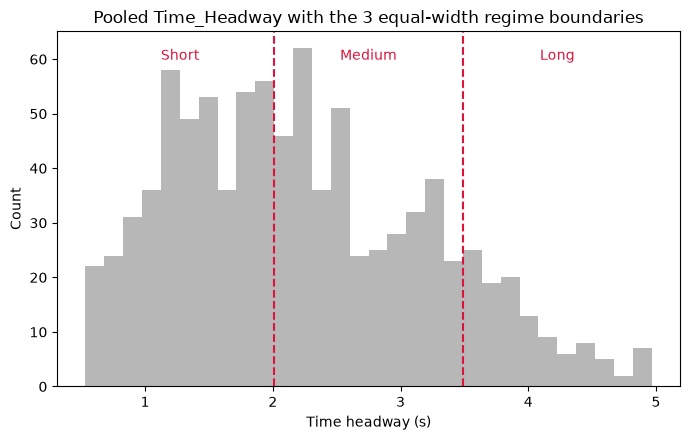

Saved: 03_regime_boundaries.png


In [7]:
# --- Cell 7: Define the 3 headway regimes and tabulate sample sizes ---
th_min, th_max = df[OUTCOME].min(), df[OUTCOME].max()
edges = np.linspace(th_min, th_max, N_REGIMES + 1)
df["TH_Regime"] = pd.cut(df[OUTCOME], bins=edges, labels=REGIME_LABELS, include_lowest=True)

regime_definition = pd.DataFrame({
    "Regime": REGIME_LABELS,
    "Lower_s": edges[:-1].round(3),
    "Upper_s": edges[1:].round(3)
})
print("Regime cut points (s):")
print(regime_definition.to_string(index=False))

regime_counts = (df.groupby([GROUPCOL, "TH_Regime"], observed=True)[OUTCOME]
                    .agg(N="count", Mean="mean", Min="min", Max="max")
                    .round(3))
print("\nSample sizes by V_Target x Regime:")
print(regime_counts.to_string())

# visualise the cut points on the pooled histogram
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df[OUTCOME], bins=30, color="#888888", alpha=0.6)
for e in edges[1:-1]:
    ax.axvline(e, color="crimson", ls="--", lw=1.5)
for lab, lo, hi in zip(REGIME_LABELS, edges[:-1], edges[1:]):
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.92, lab, ha="center", fontsize=10, color="crimson")
ax.set_xlabel("Time headway (s)")
ax.set_ylabel("Count")
ax.set_title("Pooled Time_Headway with the 3 equal-width regime boundaries")
fig.tight_layout()
fig.savefig(os.path.join(GRAPHICS, "03_regime_boundaries.png"), dpi=300)
plt.show()
print("Saved: 03_regime_boundaries.png")

In [8]:
# --- Cell 8: Run the 9-distribution fit for every V_Target x Regime cell ---
regime_segments = {}
for g in GROUP_ORDER:
    for reg in REGIME_LABELS:
        mask = (df[GROUPCOL] == g) & (df["TH_Regime"] == reg)
        regime_segments[f"{g}__{reg}"] = df.loc[mask, OUTCOME].values

t_start = time.time()
regime_fits = run_batch(regime_segments, scope="Regime", n_boot=N_BOOT, rng=RNG)
print(f"\nRegime stage done in {time.time()-t_start:.1f}s")

# split the 'Segment' label back into V_Target / TH_Regime columns for readability
split_cols = regime_fits["Segment"].str.split("__", expand=True)
regime_fits.insert(2, "V_Target", split_cols[0])
regime_fits.insert(3, "TH_Regime", split_cols[1])

regime_fits = regime_fits[["Scope", "Segment", "V_Target", "TH_Regime"] + display_cols[2:]]
regime_fits


--- Regime: BTW__Short  (n=367) ---
    [BTW__Short] gengamma     AIC=  277.66  KS_p=0.934  AD_p=0.934  (  4.9s elapsed)
    [BTW__Short] weibull_min  AIC=  361.89  KS_p=0.016  AD_p=0.016  (  5.2s elapsed)
    [BTW__Short] gamma        AIC=  377.91  KS_p=0.016  AD_p=0.016  (  5.9s elapsed)
    [BTW__Short] fisk         AIC=  401.50  KS_p=0.016  AD_p=0.016  (  7.8s elapsed)
    [BTW__Short] lognorm      AIC=  374.72  KS_p=0.016  AD_p=0.016  (  8.0s elapsed)
    [BTW__Short] invgauss     AIC=  386.63  KS_p=0.016  AD_p=0.016  (  9.1s elapsed)
    [BTW__Short] rayleigh     AIC=  393.17  KS_p=0.016  AD_p=0.016  (  9.1s elapsed)
    [BTW__Short] expon        AIC=  596.37  KS_p=0.016  AD_p=0.016  (  9.1s elapsed)
    [BTW__Short] pearson3     AIC=  361.23  KS_p=0.016  AD_p=0.016  ( 10.1s elapsed)

--- Regime: BTW__Medium  (n=256) ---
    [BTW__Medium] gengamma     AIC=  164.64  KS_p=0.016  AD_p=0.016  (  2.4s elapsed)
    [BTW__Medium] weibull_min  AIC=  215.73  KS_p=0.016  AD_p=0.016  (  2.

,Scope,Segment,V_Target,TH_Regime,N,AIC_Rank,Distribution,n_params,AIC,Delta_AIC,...,KS_p,AD_A2,AD_p,Accepted_KS,Accepted_AD,Accepted_Both,Competing_AIC,Boundary_Repaired,Degenerate_Fit,Params
0,Regime,BTW__Short,BTW,Short,367,1,gengamma,4,277.657266,0.000000,...,0.934426,548.105417,0.934426,True,True,True,True,False,False,"a=0.0018, c=711.9238, loc=0.5211, scale=1.4840"
1,Regime,BTW__Short,BTW,Short,367,2,pearson3,3,361.226249,83.568983,...,0.016393,3.282813,0.016393,False,False,False,False,False,False,"skew=-0.9692, loc=1.3579, scale=0.4266"
2,Regime,BTW__Short,BTW,Short,367,3,weibull_min,3,361.890174,84.232908,...,0.016393,2.686857,0.016393,False,False,False,False,False,False,"c=4.4823, loc=-0.1766, scale=1.6865"
3,Regime,BTW__Short,BTW,Short,367,4,lognorm,3,374.717010,97.059744,...,0.016393,2.934128,0.016393,False,False,False,False,False,False,"s=0.0000, loc=-131071.4667, scale=131072.8245"
4,Regime,BTW__Short,BTW,Short,367,5,gamma,3,377.912561,100.255295,...,0.016393,3.083061,0.016393,False,False,False,False,False,False,"a=320.2526, loc=-5.8823, scale=0.0226"
5,Regime,BTW__Short,BTW,Short,367,6,invgauss,3,386.626488,108.969222,...,0.016393,3.745072,0.016393,False,False,False,False,False,False,"mu=0.0137, loc=-2.1790, scale=258.5800"
6,Regime,BTW__Short,BTW,Short,367,7,rayleigh,2,393.167120,115.509853,...,0.016393,6.425435,0.016393,False,False,False,False,False,False,"loc=0.4820, scale=0.6808"
7,Regime,BTW__Short,BTW,Short,367,8,fisk,3,401.500990,123.843724,...,0.016393,3.277482,0.016393,False,False,False,False,False,False,"c=4179.3661, loc=-997.9394, scale=999.3102"
8,Regime,BTW__Short,BTW,Short,367,9,expon,2,596.374666,318.717399,...,0.016393,38.112960,0.016393,False,False,False,False,False,False,"loc=0.5333, scale=0.8245"
9,Regime,BTW__Medium,BTW,Medium,256,1,gengamma,4,164.643251,0.000000,...,0.016393,16.566435,0.016393,False,False,False,True,False,False,"a=0.6824, c=1.3521, loc=2.0333, scale=0.7725"


In [9]:
# --- Cell 9: Best distribution + competing set per V_Target x Regime cell ---
regime_best = summarize_best(regime_fits)
split_cols = regime_best["Segment"].str.split("__", expand=True)
regime_best.insert(2, "V_Target", split_cols[0])
regime_best.insert(3, "TH_Regime", split_cols[1])
regime_best = regime_best.sort_values(["V_Target", "TH_Regime"]).reset_index(drop=True)
regime_best

,Scope,Segment,V_Target,TH_Regime,N,Best_Distribution,AIC,KS_p,AD_p,Accepted_Both,Best_Boundary_Repaired,N_Competing,Competing_Distributions
0,Regime,BTW__Long,BTW,Long,46,gengamma,10.904991,0.344262,0.311475,True,False,0,(none within ΔAIC≤2)
1,Regime,BTW__Medium,BTW,Medium,256,gengamma,164.643251,0.016393,0.016393,False,False,0,(none within ΔAIC≤2)
2,Regime,BTW__Short,BTW,Short,367,gengamma,277.657266,0.934426,0.934426,True,False,0,(none within ΔAIC≤2)
3,Regime,PR__Long,PR,Long,68,gengamma,44.800569,0.377049,0.016393,False,False,0,(none within ΔAIC≤2)
4,Regime,PR__Medium,PR,Medium,109,gengamma,89.933224,0.016393,0.016393,False,False,0,(none within ΔAIC≤2)
5,Regime,PR__Short,PR,Short,52,gengamma,32.351719,0.606557,0.098361,True,False,0,(none within ΔAIC≤2)


In [10]:
# --- Cell 10: Acceptance matrix -- which distributions are accepted (KS & AD, p>0.05), where ---
master_fits = pd.concat([overall_fits.assign(V_Target=overall_fits["Segment"],
                                              TH_Regime="(All)"),
                          regime_fits[["Scope", "Segment", "V_Target", "TH_Regime"] + display_cols[2:]]],
                         ignore_index=True)

acceptance_matrix = (master_fits
                      .assign(Cell=lambda d: d["V_Target"] + " | " + d["TH_Regime"])
                      .pivot_table(index="Distribution", columns="Cell",
                                   values="Accepted_Both", aggfunc="first"))
# order columns sensibly: Overall first, then regimes in Short/Medium/Long order within each V_Target
col_order = [f"{g} | (All)" for g in GROUP_ORDER] + \
            [f"{g} | {r}" for g in GROUP_ORDER for r in REGIME_LABELS]
acceptance_matrix = acceptance_matrix.reindex(columns=[c for c in col_order if c in acceptance_matrix.columns])
acceptance_matrix = acceptance_matrix.fillna(False)

print("Accepted (both KS & AD, p > 0.05)?  True/False by distribution and Group|Regime cell:")
acceptance_matrix

Accepted (both KS & AD, p > 0.05)?  True/False by distribution and Group|Regime cell:


Cell,BTW | (All),PR | (All),BTW | Short,BTW | Medium,BTW | Long,PR | Short,PR | Medium,PR | Long
Distribution,,,,,,,,
expon,False,False,False,False,True,False,False,False
fisk,False,False,False,False,True,False,False,True
gamma,False,False,False,True,True,False,False,True
gengamma,True,True,True,False,True,True,False,False
invgauss,False,False,False,False,True,False,False,True
lognorm,False,False,False,False,True,False,False,True
pearson3,False,False,False,False,True,True,False,True
rayleigh,True,False,False,False,False,False,False,False
weibull_min,True,False,False,False,True,True,False,True


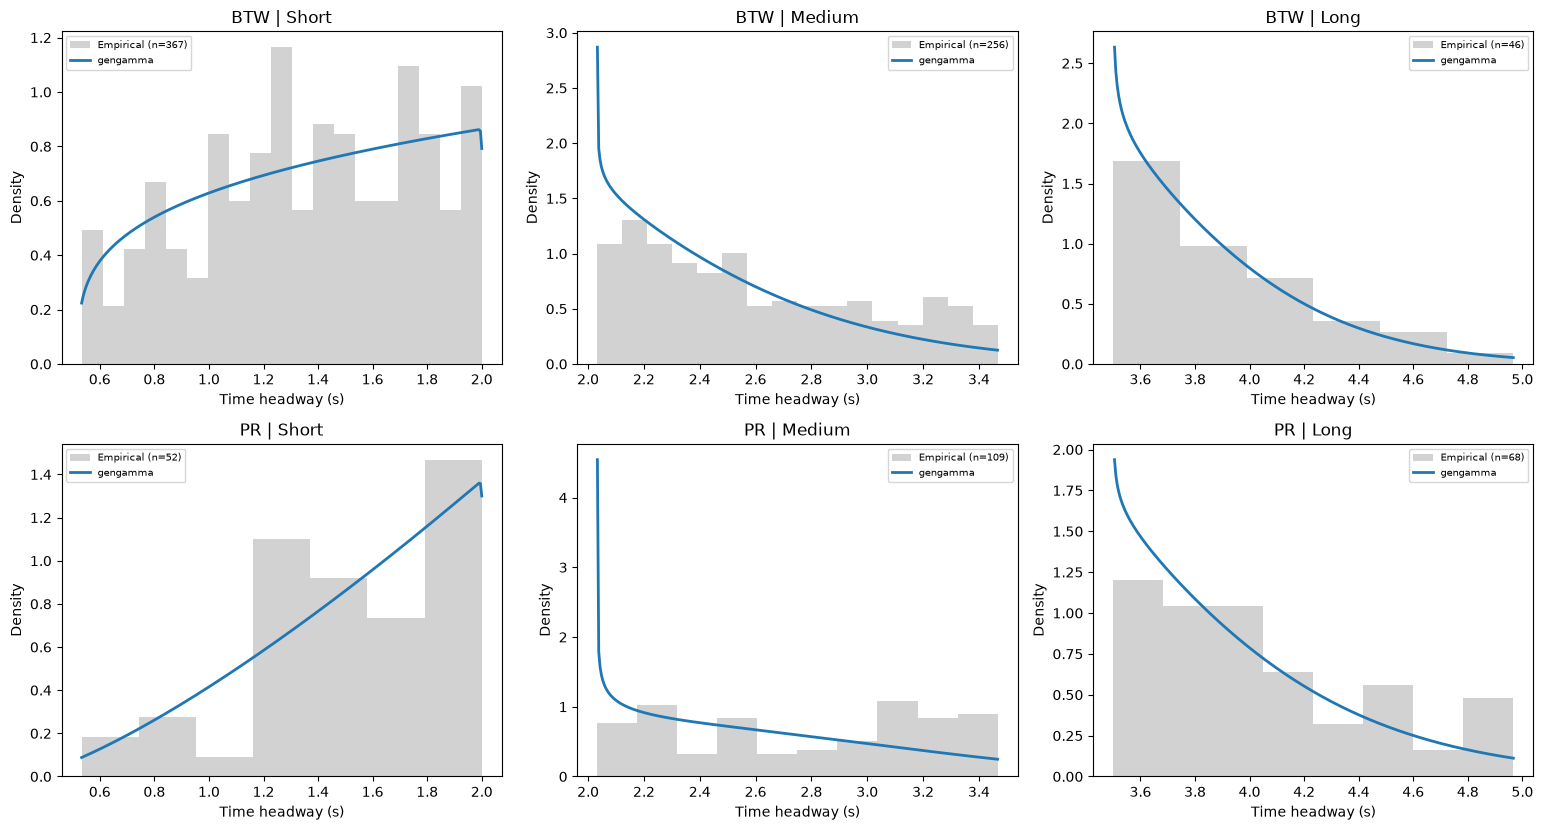

Saved: 04_regime_fit_grid.png


In [11]:
# --- Cell 11: Grid of histogram + best-fit-PDF overlays, V_Target x Regime ---
fig, axes = plt.subplots(len(GROUP_ORDER), N_REGIMES,
                          figsize=(5.2 * N_REGIMES, 4.2 * len(GROUP_ORDER)), squeeze=False)

for i, g in enumerate(GROUP_ORDER):
    for j, reg in enumerate(REGIME_LABELS):
        ax = axes[i][j]
        seg_label = f"{g}__{reg}"
        data = regime_segments.get(seg_label, np.array([]))
        sub = regime_fits[regime_fits["Segment"] == seg_label].sort_values("AIC_Rank")
        if len(data) == 0 or sub.empty:
            ax.set_title(f"{g} | {reg}: n={len(data)} (skipped)")
            ax.axis("off")
            continue
        ax.hist(data, bins=min(20, max(5, int(np.sqrt(len(data))))), density=True,
                alpha=0.35, color="gray", label=f"Empirical (n={len(data)})")
        xg = np.linspace(data.min(), data.max(), 300)
        top = sub[sub["Competing_AIC"]] if sub["Competing_AIC"].sum() > 1 else sub.head(1)
        for _, row in top.iterrows():
            dist = getattr(stats, row["Distribution"])
            raw_params = [float(v.split("=")[1]) for v in row["Params"].split(", ")]
            yg = dist.pdf(xg, *raw_params)
            ax.plot(xg, yg, lw=2, label=f"{row['Distribution']}")
        ax.set_title(f"{g} | {reg}")
        ax.set_xlabel("Time headway (s)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(GRAPHICS, "04_regime_fit_grid.png"), dpi=300)
plt.show()
print("Saved: 04_regime_fit_grid.png")

In [12]:
# --- Cell 12: Save all tables to the Tables folder (Excel workbook) ---
out_path = os.path.join(TABLES, "headway_distribution_fits_PR_BTW.xlsx")

export_cols = [c for c in display_cols if c != "Params"] + ["Params"]  # keep Params last

with pd.ExcelWriter(out_path, engine="openpyxl") as xl:
    regime_definition.to_excel(xl, sheet_name="Regime_Definition", index=False)
    regime_counts.reset_index().to_excel(xl, sheet_name="Regime_Sample_Sizes", index=False)
    overall_fits[export_cols].to_excel(xl, sheet_name="Overall_All_Fits", index=False)
    overall_best.to_excel(xl, sheet_name="Overall_Best", index=False)
    regime_fits[["Scope", "Segment", "V_Target", "TH_Regime"] + [c for c in export_cols if c not in ("Scope","Segment")]].to_excel(
        xl, sheet_name="Regime_All_Fits", index=False)
    regime_best.to_excel(xl, sheet_name="Regime_Best", index=False)
    acceptance_matrix.reset_index().to_excel(xl, sheet_name="Acceptance_Matrix", index=False)

print("Saved workbook:", out_path)
print("Sheets: Regime_Definition, Regime_Sample_Sizes, Overall_All_Fits, Overall_Best,",
      "Regime_All_Fits, Regime_Best, Acceptance_Matrix")

Saved workbook: D:\Headway\Tables\headway_distribution_fits_PR_BTW.xlsx
Sheets: Regime_Definition, Regime_Sample_Sizes, Overall_All_Fits, Overall_Best, Regime_All_Fits, Regime_Best, Acceptance_Matrix


## Notes for the manuscript / next steps

- **Runtime & precision of p-values.** `QUICK_MODE = True` (Cell 1) uses only `N_BOOT = 60`
  bootstrap replicates per fit so you can sanity-check the whole pipeline quickly. For the numbers
  that go into the manuscript, set `QUICK_MODE = False` (→ `N_BOOT = 300`) and re-run — this will
  take noticeably longer (`gengamma` and `invgauss` are the slow ones) but gives p-values with
  finer resolution (1/301 ≈ 0.0033 vs 1/61 ≈ 0.016).
- **"Only 1 distribution, but flag close competitors"** is implemented as `Competing_AIC`
  (ΔAIC ≤ 2, the standard Burnham & Anderson cut-off) plus the `AIC_weight` column, which gives a
  continuous measure of relative support — useful if a reviewer asks how confident the pick is.
- **Regime definition** currently uses **equal-width** bins over the pooled observed range
  (`Short`/`Medium`/`Long`), since both classes share essentially the same min/max. If you'd rather
  regimes be equal-*count* (tertiles) or anchored to specific policy-relevant thresholds (e.g. a
  2s "risky following" cut-off used in the safety literature), tell me and I'll swap the edges in
  Cell 7 — everything downstream is generic to whatever `edges`/`REGIME_LABELS` you set.
- **Small regimes.** Check `Regime_Sample_Sizes` once you've run Cell 7 — cells below `MIN_N_FIT`
  (15) are silently skipped in the fitting loop and will show as blank/`False` columns in the
  acceptance matrix.
- Run this, and send me back the printed output / any errors — I'll debug from there.
